In [23]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
df= pd.read_csv("../data/processed_sales_data.csv")

In [25]:
df.isnull().sum()

State             0
Date              0
Total             0
lag_1             0
lag_7             0
lag_30            0
rolling_mean_7    6
rolling_std_7     0
dayofweek         0
month             0
week              0
dtype: int64

In [26]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [27]:
df.head()

,State,Date,Total,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,dayofweek,month,week
0,Oklahoma,2019-11-17,78375343,239914025.0,14151732.0,172375681.0,1.437504e+08,3.024879e+06,6,11,46
1,Rhode Island,2019-11-17,13802172,78375343.0,202076105.0,38349706.0,1.168541e+08,5.352382e+05,6,11,46
2,Texas,2019-11-17,478104629,13802172.0,61015742.0,12021378.0,1.764383e+08,2.366514e+07,6,11,46
3,South Dakota,2019-11-17,16008107,478104629.0,37154366.0,17193457.0,1.734174e+08,3.703277e+05,6,11,46
4,Tennessee,2019-11-17,135190491,16008107.0,200628466.0,102978285.0,1.640691e+08,7.550985e+06,6,11,46


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['State_encoded'] = le.fit_transform(df['State'])

In [40]:
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'dayofweek',
    'month',
    'week',
    'State_encoded'
]

SARIMA

In [33]:
top_states = (
    df.groupby('State')['Total']
      .sum()
      .sort_values(ascending=False)
      .head(3)
      .index
)


In [32]:
top_states

Index(['Texas', 'California', 'Florida'], dtype='str', name='State')

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


Training SARIMA for Texas
MAE: 181149941.25898728
RMSE: 197528987.8369361


c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


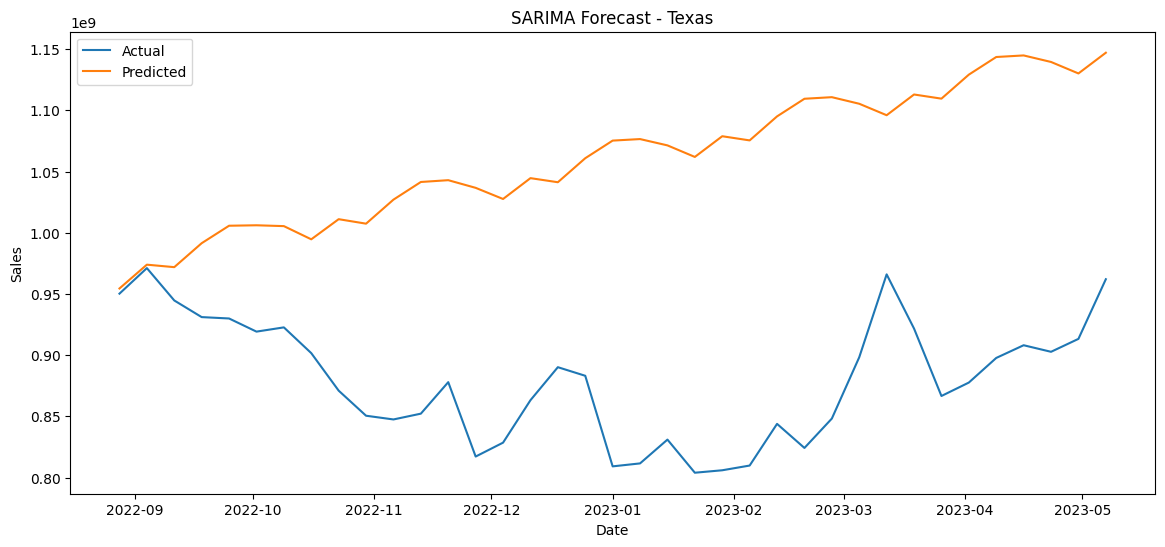

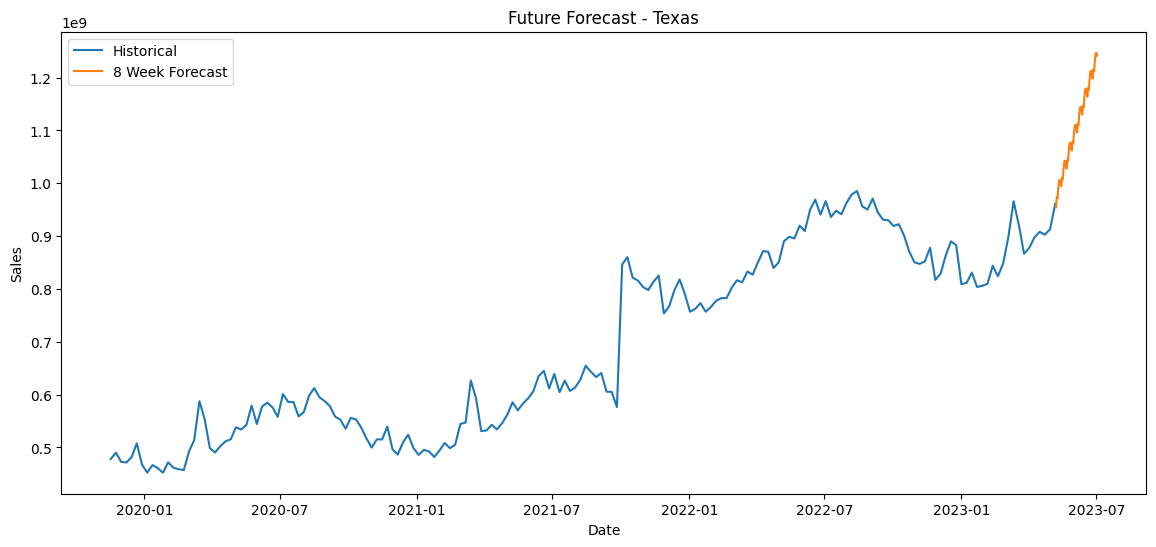


Training SARIMA for California
MAE: 177699292.46134537
RMSE: 192431421.6063456


c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


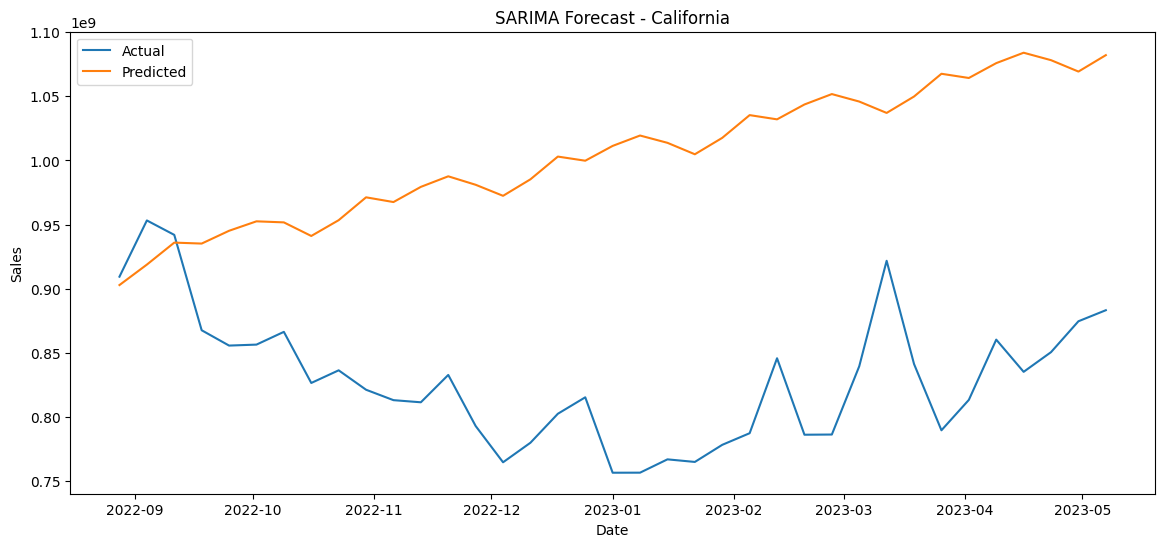

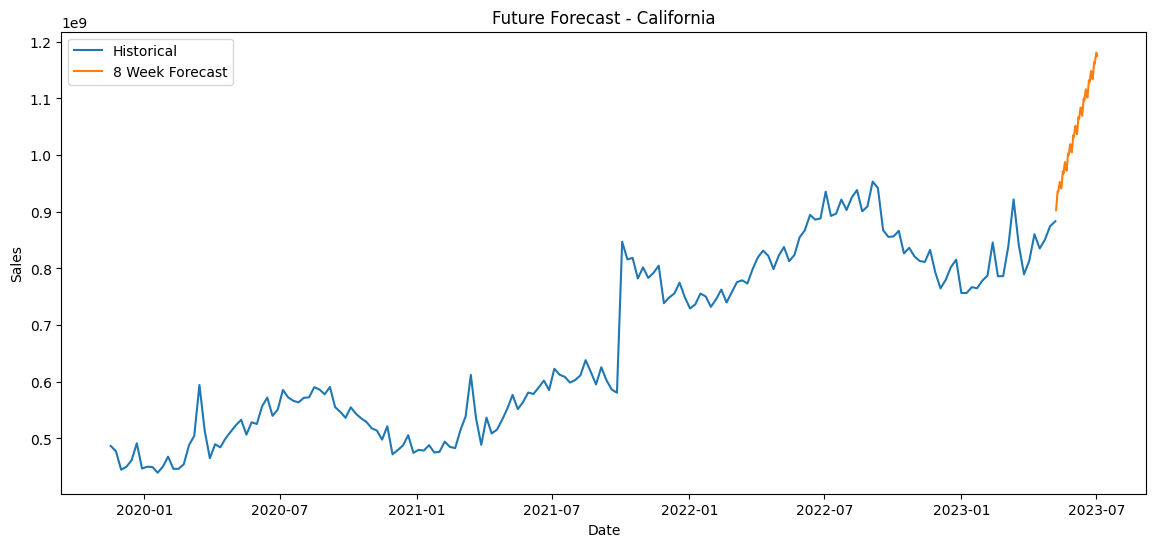


Training SARIMA for Florida
MAE: 41974922.54761807
RMSE: 48802999.86021781


c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


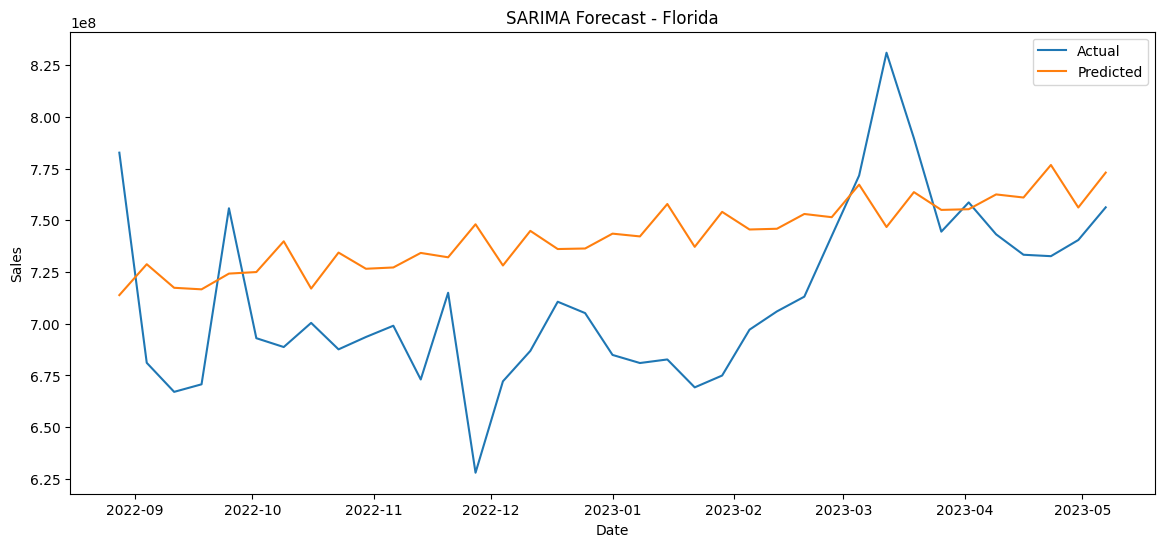

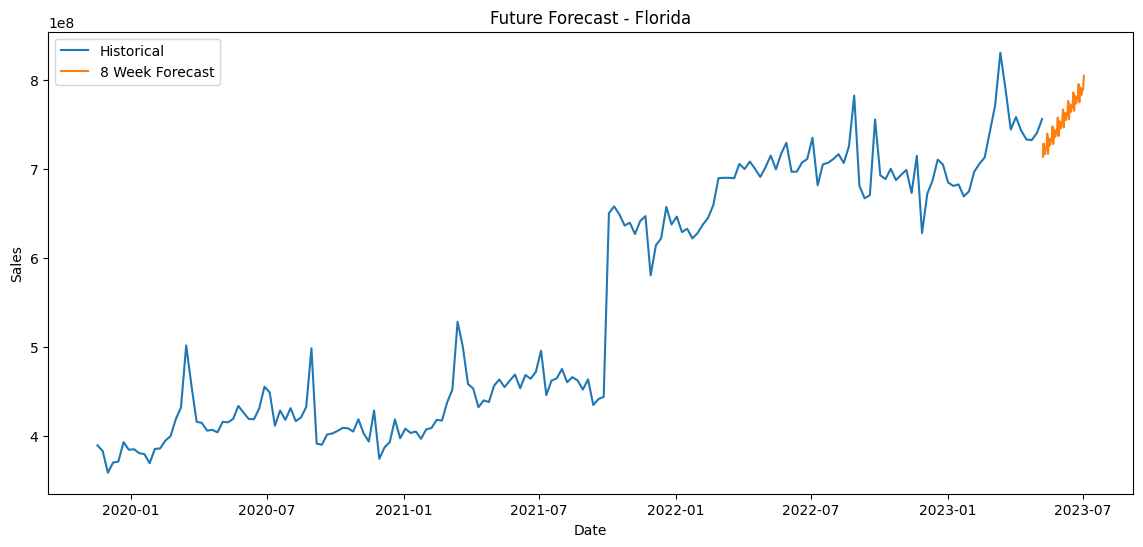


Model Performance:
        State           MAE          RMSE
0       Texas  1.811499e+08  1.975290e+08
1  California  1.776993e+08  1.924314e+08
2     Florida  4.197492e+07  4.880300e+07


In [48]:
results = []
sarima_mae = 0
sarima_rmse = 0
df['Date'] = pd.to_datetime(df['Date'])
for state in top_states:
    print(f"\nTraining SARIMA for {state}")
    state_df = df[df['State'] == state].copy()
    state_df = state_df.sort_values('Date')
    state_df.set_index('Date', inplace=True)
    y = state_df['Total']

    train_size = int(len(y) * 0.8)
    train = y[:train_size]
    test = y[train_size:]

    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    model_fit = model.fit(disp=False)

    predictions = model_fit.forecast(steps=len(test))
    mae = mean_absolute_error(test, predictions)
    rmse = np.sqrt(mean_squared_error(test, predictions))
    sarima_mae += mae
    sarima_rmse += rmse

    print("MAE:", mae)
    print("RMSE:", rmse)

    results.append({'State': state, 'MAE': mae, 'RMSE': rmse})

    plt.figure(figsize=(14,6))
    plt.plot(test.index, test.values, label='Actual')
    plt.plot(test.index, predictions, label='Predicted')
    plt.title(f'SARIMA Forecast - {state}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

    future_forecast = model_fit.forecast(steps=56)
    future_dates = pd.date_range(start=state_df.index[-1], periods=57, freq='D')[1:]

    plt.figure(figsize=(14,6))
    plt.plot(state_df.index, state_df['Total'], label='Historical')
    plt.plot(future_dates, future_forecast, label='8 Week Forecast')
    plt.title(f'Future Forecast - {state}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

results_df = pd.DataFrame(results)
sarima_mae = sarima_mae / len(top_states)
sarima_rmse = sarima_rmse / len(top_states)
print("\nModel Performance:")
print(results_df)


In [36]:
from prophet import Prophet

c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


20:56:55 - cmdstanpy - INFO - Chain [1] start processing



Training Prophet for Texas


20:56:55 - cmdstanpy - INFO - Chain [1] done processing


MAE: 198804971.75460142
RMSE: 212142516.50700173


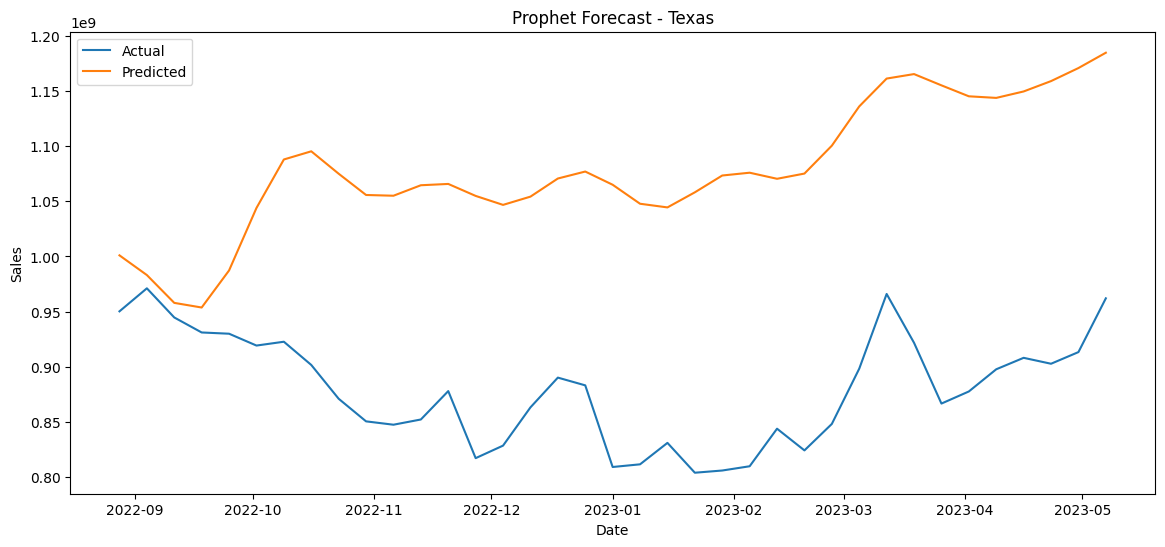

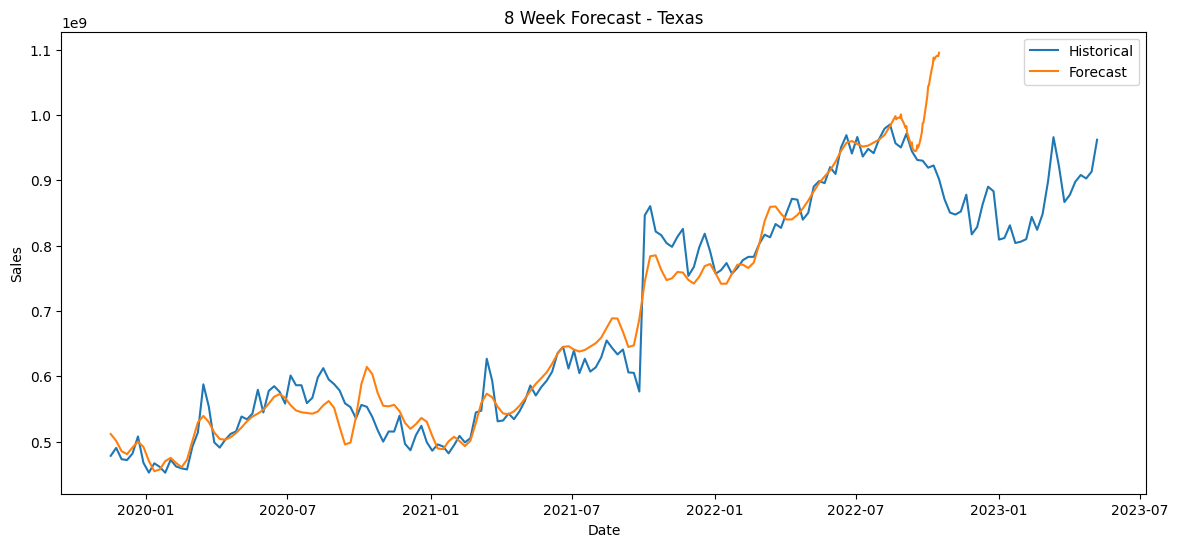

20:56:55 - cmdstanpy - INFO - Chain [1] start processing
20:56:55 - cmdstanpy - INFO - Chain [1] done processing



Training Prophet for California
MAE: 190964369.42838752
RMSE: 201645413.62607223


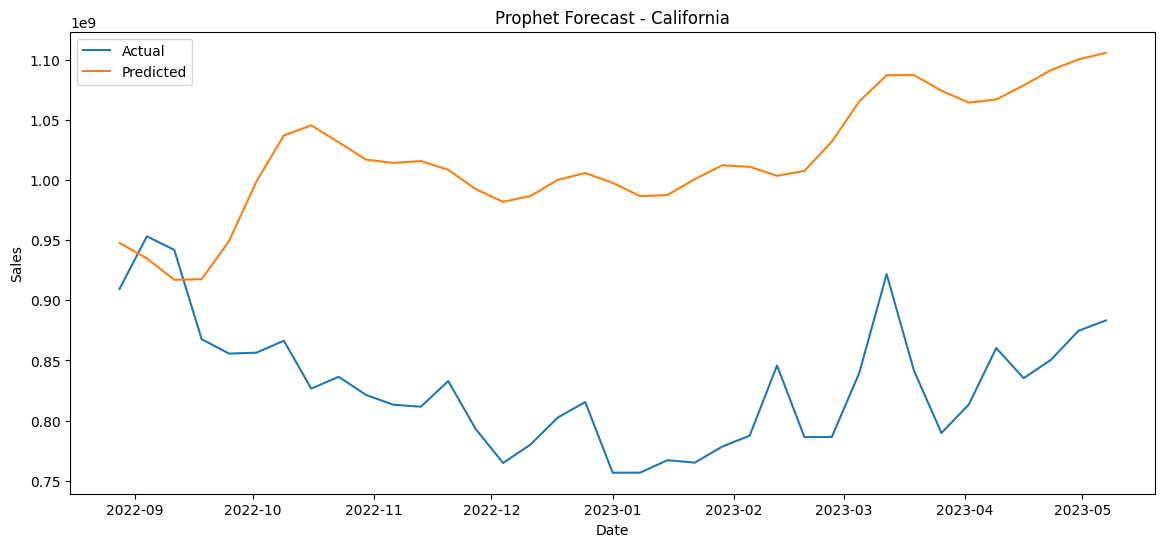

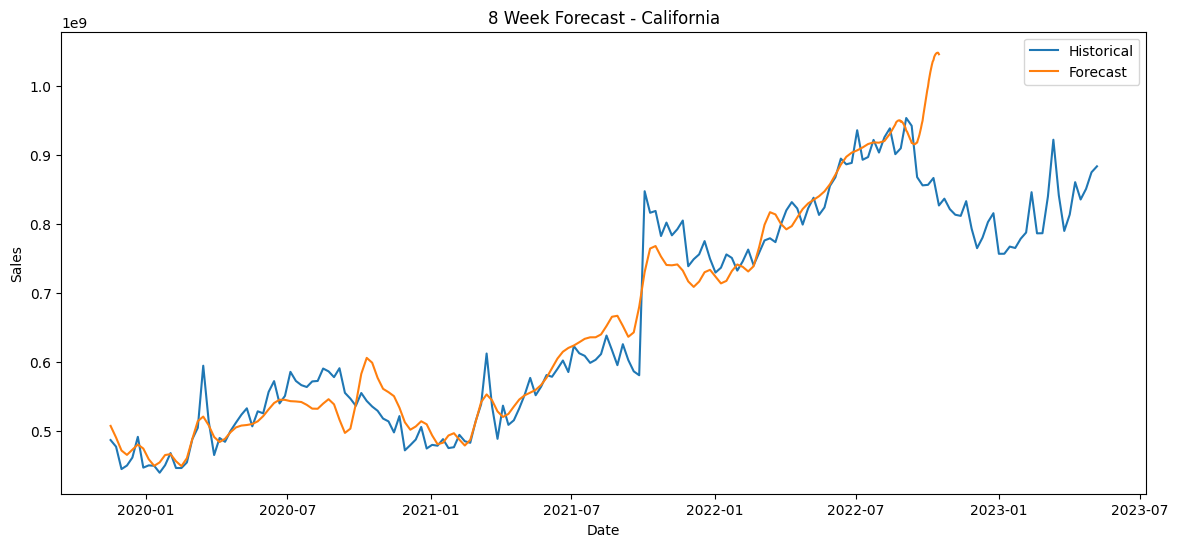

20:56:56 - cmdstanpy - INFO - Chain [1] start processing
20:56:56 - cmdstanpy - INFO - Chain [1] done processing



Training Prophet for Florida
MAE: 128794077.8943378
RMSE: 135212592.92575774


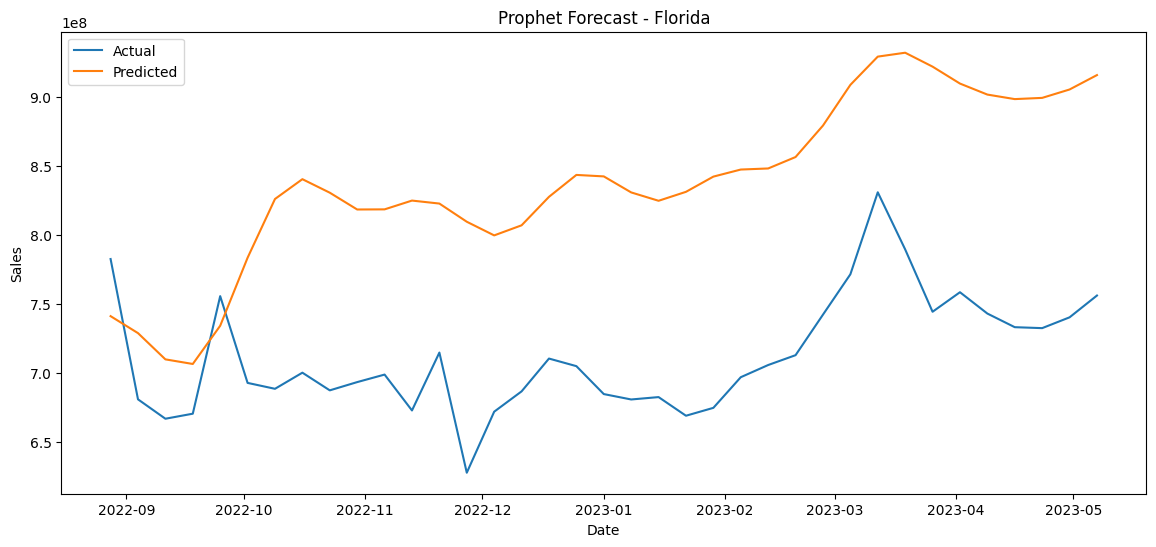

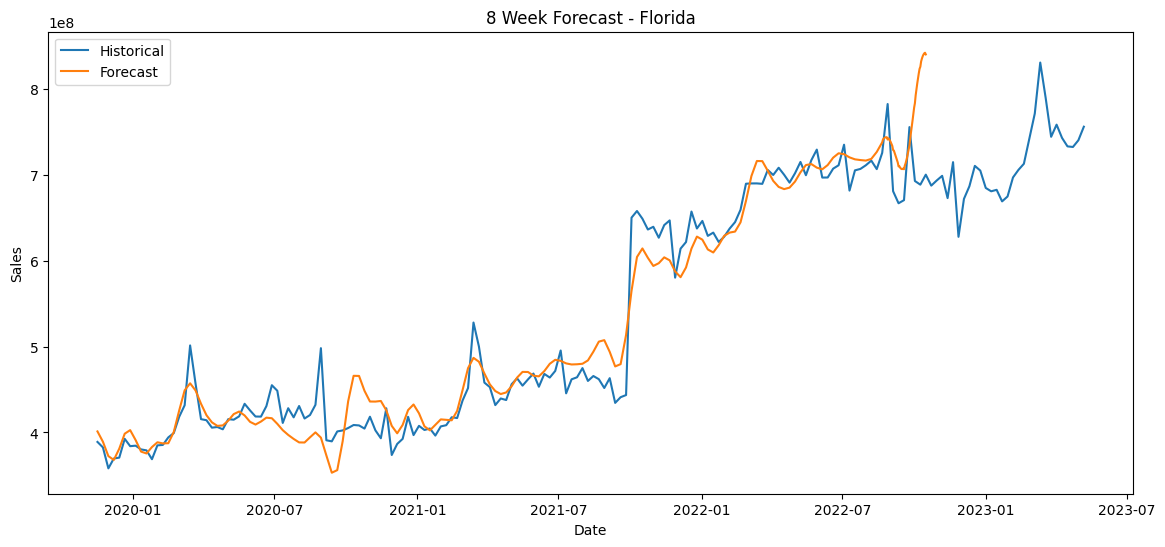


Prophet Model Performance:
        State           MAE          RMSE
0       Texas  1.988050e+08  2.121425e+08
1  California  1.909644e+08  2.016454e+08
2     Florida  1.287941e+08  1.352126e+08


In [49]:
results = []
prop_mae= 0
prop_rmse = 0

for state in top_states:
    print(f"\nTraining Prophet for {state}")
    state_df = df[df['State'] == state].copy()
    state_df = state_df.sort_values('Date')
    prophet_df = state_df[['Date', 'Total']].copy()
    prophet_df.columns = ['ds', 'y']

    train_size = int(len(prophet_df) * 0.8)
    train = prophet_df.iloc[:train_size]
    test = prophet_df.iloc[train_size:]

    model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(train)

    future_test = test[['ds']]
    forecast_test = model.predict(future_test)
    predictions = forecast_test['yhat'].values

    mae = mean_absolute_error(test['y'], predictions)
    rmse = np.sqrt(mean_squared_error(test['y'], predictions))
    prop_mae += mae
    prop_rmse += rmse

    print("MAE:", mae)
    print("RMSE:", rmse)

    results.append({'State': state, 'MAE': mae, 'RMSE': rmse})

    plt.figure(figsize=(14,6))
    plt.plot(test['ds'], test['y'], label='Actual')
    plt.plot(test['ds'], predictions, label='Predicted')
    plt.title(f'Prophet Forecast - {state}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

    future = model.make_future_dataframe(periods=56, freq='D')
    forecast_future = model.predict(future)

    plt.figure(figsize=(14,6))
    plt.plot(prophet_df['ds'], prophet_df['y'], label='Historical')
    plt.plot(forecast_future['ds'], forecast_future['yhat'], label='Forecast')
    plt.title(f'8 Week Forecast - {state}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

results_df = pd.DataFrame(results)
prophet_mae= prop_mae / len(top_states)
prophet_rmse = prop_rmse / len(top_states)
print("\nProphet Model Performance:")
print(results_df)

XGBoost

In [42]:
from xgboost import XGBRegressor

XGBoost MAE: 98015544.0
XGBoost RMSE: 184845841.8739864


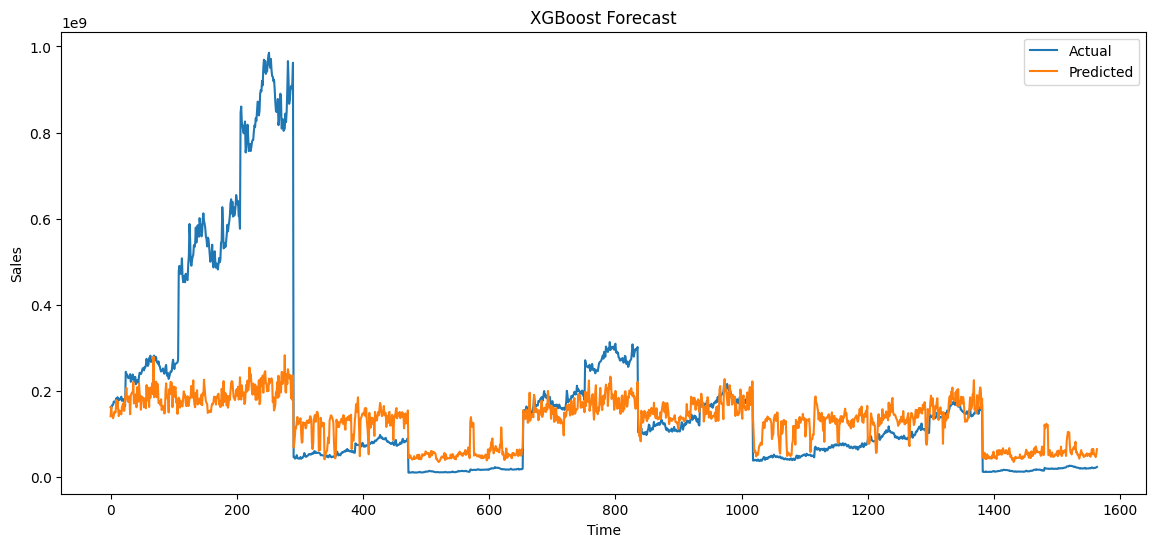

          Feature  Importance
4   rolling_std_7    0.542108
8   State_encoded    0.251379
3  rolling_mean_7    0.089052
0           lag_1    0.047889
7            week    0.023237
6           month    0.022065
1           lag_7    0.013545
2          lag_30    0.010726
5       dayofweek    0.000000


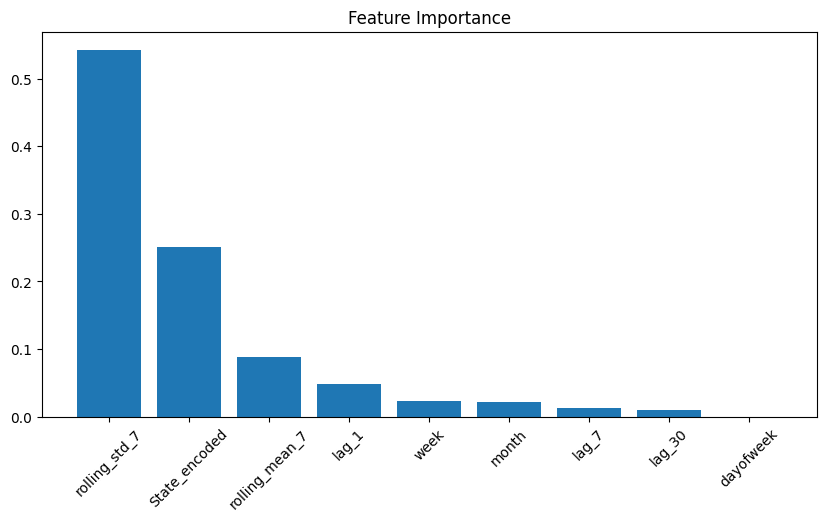

In [50]:
df = df.sort_values(['State', 'Date'])
target = 'Total'

train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title('XGBoost Forecast')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

importance = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.show()


In [45]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

Epoch 1/20


c:\Users\naman\OneDrive\Desktop\quickhyre assignment\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.8479e-04 - val_loss: 0.0014
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5401e-04 - val_loss: 0.0015
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.1314e-04 - val_loss: 0.0012
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3050e-04 - val_loss: 0.0010
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.9215e-04 - val_loss: 9.7466e-04
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.5549e-04 - val_loss: 9.4397e-04
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.4840e-04 - val_loss: 9.1505e-04
Epoch 9/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.1381e-04 - val_loss: 0.0011
Epoch 10/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.1366e-04 - val_loss: 8.6712e-04
Epoch 11/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.0520e-04 - val_loss: 8.7890e-04
Epo

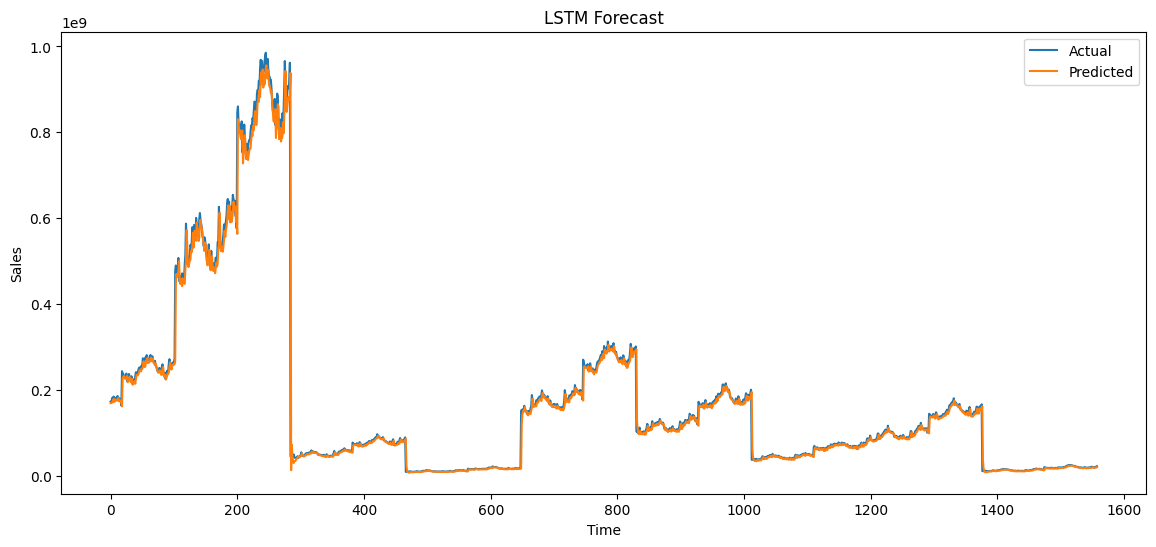

In [ ]:
data = df['Total'].values.reshape(-1,1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

sequence_length = 30
X, y = [], []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False,random_state=42)

model = Sequential()
model.add(LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

lstm_mae = mean_absolute_error(y_test_actual, predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title('LSTM Forecast')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [52]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost', 'LSTM'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae, lstm_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse, lstm_rmse]
})

print(comparison)

     Model           MAE          RMSE
0   SARIMA  1.336081e+08  1.462545e+08
1  Prophet  1.728545e+08  1.830002e+08
2  XGBoost  9.801554e+07  1.848458e+08
3     LSTM  7.913748e+06  2.853223e+07


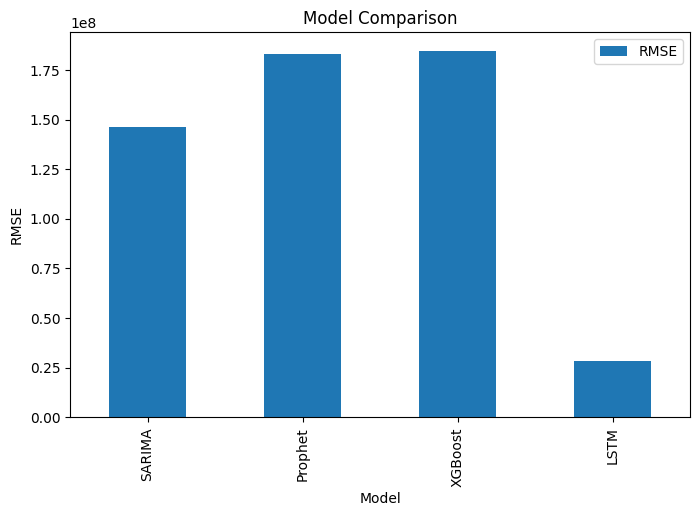

In [53]:
comparison.plot(
    x='Model',
    y='RMSE',
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Comparison')

plt.ylabel('RMSE')

plt.show()

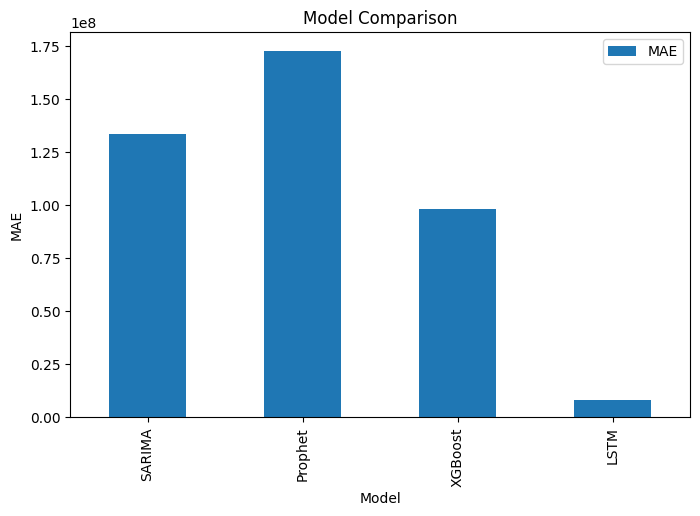

In [54]:
comparison.plot(
    x='Model',
    y='MAE',
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Comparison')

plt.ylabel('MAE')

plt.show()

Among all forecasting models tested, the LSTM model achieved the lowest RMSE and MAE, indicating superior performance in capturing temporal dependencies and nonlinear sales patterns.

Traditional statistical models like SARIMA and Prophet performed reasonably well for individual states, while XGBoost showed strong feature based forecasting capability. However, LSTM provided the most accurate overall forecasting performance.

In [55]:
last_sequence = scaled_data[-30:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(56):

    pred = model.predict(
        current_sequence.reshape(1,30,1),
        verbose=0
    )

    future_predictions.append(pred[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    )

future_predictions = np.array(future_predictions)

future_predictions = scaler.inverse_transform(
    future_predictions.reshape(-1,1)
)

future_dates = pd.date_range(
    start=df['Date'].max() + pd.Timedelta(days=1),
    periods=56,
    freq='D'
)

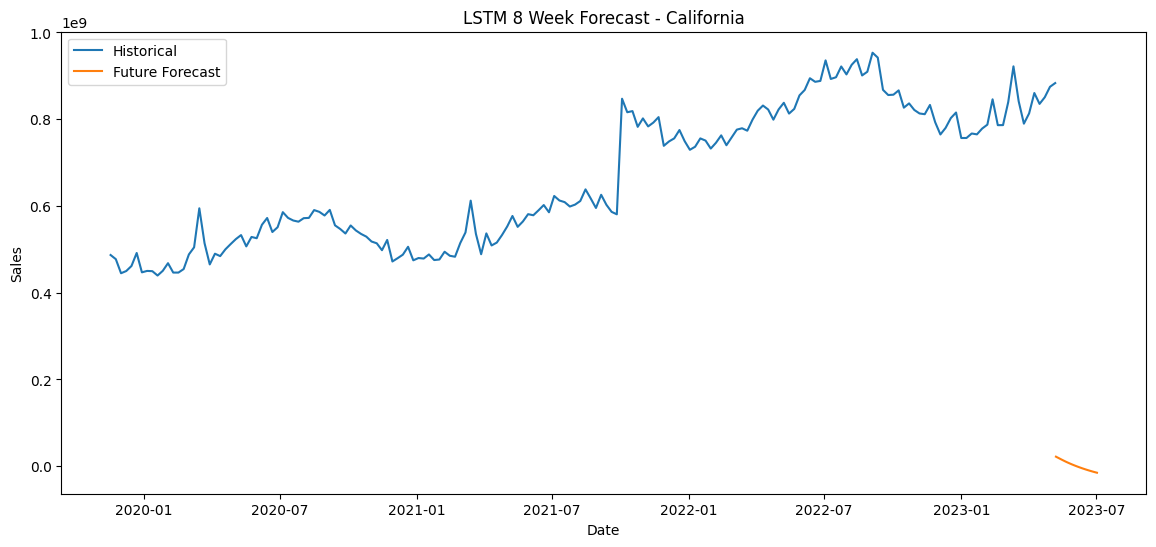

In [57]:
state_df = df[df['State'] == 'California'].copy()

state_df = state_df.sort_values('Date')
plt.figure(figsize=(14,6))

plt.plot(
    state_df['Date'],
    state_df['Total'],
    label='Historical'
)

plt.plot(
    future_dates,
    future_predictions,
    label='Future Forecast'
)

plt.title('LSTM 8 Week Forecast - California')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.legend()

plt.show()

In [59]:
best_model = comparison.loc[
    comparison['RMSE'].idxmin()
]
model.save('best_lstm_sales_forecast.keras')